In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys

sys.path.append('/home/admin/Documents/98_model/src')
sys.path.append('/data01/Documents/98_model/src')
sys.path.append('/data/98_model/src')

# Import modules

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display

import seaborn as sns
import xgboost as xgb
import yaml
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import KFold

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import xgboost as xgb
from tqdm import tqdm
import re
import pickle
from sklearn.metrics import roc_curve, auc
import re

from tqdm import trange
import pickle
import os
import optuna

from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend
import threading
import gc

from sklearn.manifold import TSNE
import umap
import dill
from matplotlib.patches import FancyArrowPatch
from sklearn.metrics import root_mean_squared_error

from model_v5 import CascadeModel
from plotly.io import show

/home/admin/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/admin/.venv/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [ ]:
from utils import PROCESS_STEPS, INPUT_PROFILE, DATA_TYPES
from utils import ColumnClassifier
from utils import squeeze_list

# Environment variables

In [ ]:
SHOW_DISTRIBUTION = False
PERFORM_CROSS_VALIDATION = True
PERFORM_BACKTEST = True

In [ ]:
FILEPATH_PCA_MODEL_SV = 'PCA_MODEL_SV.dill'
FILEPATH_PCA_MODEL_IQC = 'PCA_MODEL_IQC.dill'
FILEPATH_PCA_MODEL_SV_IQC = 'PCA_MODEL_SV_IQC.dill'

In [ ]:
model_name = 'N32S'                 # 대상 모델명
n_trials = 500                      # Optuna 최적화 시도 횟수
lb_margin = 0.05                    # 하한값 마진 비율(기준 최소값 대비)
ub_margin = 0.05                    # 상한값 마진 비율(기준 최대값 대비)
threshold_constraint = 4            # 제약 고정 컬럼 판별 기준(고유값 개수 임계치)

model_version = 'v5'                # 모델 버전 식별자

# Load data

In [ ]:
try : 
    data_path = '/home/admin/Documents/98_model/notebooks/260714_feature_engineering_qa/feature_store_v10_n32s.parquet'
    data = pd.read_parquet(data_path)
except : 
    try : 
        data_path = '/data01/Documents/98_model/notebooks/260714_feature_engineering_qa/feature_store_v10_n32s.parquet'
        data = pd.read_parquet(data_path)
    except : 
        data_path = '/data/98_model/notebooks/260714_feature_engineering_qa/feature_store_v10_n32s.parquet'
        data = pd.read_parquet(data_path)
data

,07_Before Degas_Cell ID,BASE_ID,01_Mixing_Lot ID,01_Mixing_Equipment ID,01_Mixing_Finished Date,02_Coating(Back)_Lot ID,02_Coating(Back)_Equipment ID,02_Coating(Back)_Finished Date,03_Roll Pressing_Lot ID,03_Roll Pressing_Equipment ID,...,DV86__음극 Buffer 수동 장력 * 가속도 WINDING 1,DV86__음극 Buffer 수동 장력 * 가속도 WINDING 2,DV86__양극 스풀 장력 * 가속도 WINDING 1,DV86__양극 스풀 장력 * 가속도 WINDING 2,DV88_ABW_용접 시간xVoltage,DV88_CSZ_용접 시간xVoltage,DV88_CRW_용접 시간xVoltage,DV88_CBD_용접 시간xVoltage,DV88_CCR_용접 시간xVoltage,DV88_ELF_용접 시간xVoltage
0,07TCED7LGC0021G2B2016718,59JFB112A1,5A2F201001,M2EMIX01602,2026-02-02 01:28:10,5CF1T1A5C1,M2ECOT001,2026-01-30 06:12:56,5CF1T1A5R2,M2EROL015,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,07TCED7LGC0021G2E2063322,59JFB142A1,5A2F201001,M2EMIX01602,2026-02-02 01:28:10,5AF2A131C1,M2ECOT002,2026-02-10 14:14:12,5AF2A131R1,M2EROL014,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,07TCED7LGC0021G2G2018702,59JFB162A1,5A3F209041,M2EMIX01702,2026-02-09 19:11:46,5CF1V165C1,M2ECOT001,2026-01-31 18:56:59,5CF1V165R1,M2EROL015,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,07TCED7LGC0021G382040158,59JFC082A1,5C1F225029,M2EMIX01103,2026-02-26 00:00:57,5CF2R151C1,M2ECOT001,2026-02-27 17:44:29,5CF2R151R1,M2EROL015,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,07TCED7LGC0021G3S2044730,59JFC252A1,5C2F309007,M2EMIX01203,2026-03-09 21:02:14,5CF3E183C1,M2ECOT001,2026-03-14 20:58:31,5CF3E183R1,M2EROL015,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14824,None,59JFC302A1,5A4F320066,M2EMIX01802,2026-03-20 15:59:56,5AF3K177C1,M2ECOT002,2026-03-20 23:44:37,5AF3K177R1,M2EROL014,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14825,None,59JFC302A1,5C1F324051,M2EMIX01103,2026-03-24 15:31:54,5CF3P182C1,M2ECOT001,2026-03-25 22:57:45,5CF3P182R1,M2EROL012,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14826,None,59JFC302A1,5C2F324047,M2EMIX01203,2026-03-24 12:58:56,5CF3P135C1,M2ECOT001,2026-03-25 14:02:37,5CF3P135R1,M2EROL015,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14827,None,59JFC302A1,5C2F324047,M2EMIX01203,2026-03-24 12:58:56,5CF3P164C1,M2ECOT001,2026-03-25 19:24:35,5CF3P164R1,M2EROL012,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
data_path_weekly_defect = '/home/admin/Documents/98_model/data/weekly_defect_n32s.parquet'
data_path_weekly_defect_vm2 = '/data01/Documents/98_model/data/weekly_defect_n32s.parquet'
data_path_weekly_defect_vm1 = '/data/98_model/data/weekly_defect_n32s.parquet'

try : 
    weekly_score = pd.read_parquet(data_path_weekly_defect)
except : 
    try : 
        weekly_score = pd.read_parquet(data_path_weekly_defect_vm2)
    except : 
        weekly_score = pd.read_parquet(data_path_weekly_defect_vm1)

In [11]:
weekly_score.head().T

,0,1,2,3,4
date,2026.01.25-2026.01.31,2026.02.01-2026.02.07,2026.02.08-2026.02.14,2026.02.15-2026.02.21,2026.02.22-2026.02.28
week,5,6,7,8,9
Y_NFF_A,0.997249,0.996782,0.997993,0.998562,0.996932
Y_NFF_B,0.0,0.0,0.0,0.0,0.0
Y_NFF_C,0.0,0.0,0.0,0.0,0.0
Y_NFF_D,0.000045,0.000101,0.000134,0.000075,0.000164
Y_NFF_E,0.000435,0.000564,0.00048,0.000534,0.000457
Y_NFF_F,0.000007,0.0,0.0,0.0,0.0
Y_NFF_G,0.0,0.0,0.0,0.0,0.0
Y_NFF_H,0.00036,0.00022,0.000289,0.000368,0.000287


# Get column names

In [ ]:
# ColumnClassifier: 컬럼을 데이터 타입별로 분류하는 유틸리티 클래스
column_classifier = ColumnClassifier()
# transform: data의 컬럼을 분석하여 data_type, cols 등의 정보를 담은 DataFrame 반환
df_cols = column_classifier.transform(data=data)

In [ ]:
# df_cols에서 데이터 타입이 'Small_Y'인 행만 필터링하여
# 'cols' 컬럼의 값을 리스트로 추출
cols_small_y = (
    df_cols.loc[lambda x: x['data_type'] == 'Small_Y', 'cols']
    .tolist()
)
# squeeze_list로 중첩 리스트 평탄화 후 data에 존재하는 컬럼만 필터링
cols_small_y = squeeze_list(cols_small_y)
cols_small_y = [x for x in cols_small_y if x in data.columns]
cols_small_y[:5]

['y_MES_Electrode_Coating_Anode_절연 (Back)',
 'y_MES_Electrode_Coating_Anode_외관_접힘 (Top)',
 'y_MES_Electrode_Coating_Cathode_외관_접힘 (Back)',
 'y_MES_Electrode_Coating_Cathode_외관_표면 (Back)',
 'y_MES_Electrode_Coating_Cathode_치수_Mismatch (Back)']

In [14]:
cols_sv = (
    df_cols.loc[lambda x :x['data_type'] == 'SV', 'cols']
    .tolist()
)
cols_sv = squeeze_list(cols_sv)
cols_sv[:5]

['X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time',
 'X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6',
 'X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']

In [15]:
cols_major_sv = [
    
]
# TODO : 주요 SV 받아서 변경 필요

cols_minor_sv = [

]

In [16]:
cols_big_y = [
    'Y_NFF_A',
    'Y_NFF_E',
    'Y_NFF_J',
    'Y_NFF_F',
    'Y_NFF_R',
    'Y_NFF_V'
]

In [17]:
cols_iqc = [x for x in data.columns if 'IQC' in x]
cols_iqc[:5]

['X_IQC_Assemble_Assembly_두께_1',
 'X_IQC_Assemble_Assembly_돌기부_외경',
 'X_IQC_Assemble_Assembly_중심부Hole_동심도',
 'X_IQC_Assemble_Assembly_외경',
 'X_IQC_Assemble_Assembly_두께_4']

# Preprocess data

In [18]:
# 0. Big Y 없는 row 제거
data = data[data['Y_NFF_A'].notnull()]

In [19]:
# 1. 중복 컬럼 제거
data = data.loc[:, ~data.columns.duplicated()]

In [20]:
# 2. datetime 처리
col_target_date = '06_Assembly_Finished Date'
data[col_target_date] = pd.to_datetime(data[col_target_date])
data['week'] = data[col_target_date].dt.isocalendar().week
data['date'] = data[col_target_date].dt.date

In [21]:
# 3. Category로 되어있는 Small y 인코딩
def encode_small_y(x) :
    # NG -> 불량 -> 1
    # OK -> 정상 -> 0
    if x == 'NG' :
        y = 1
    elif x == 'OK' : 
        y = 0 
    else : 
        y = x
    return y

for col in tqdm(cols_small_y) : 
    data[col] = data[col].apply(lambda x: encode_small_y(x))
    

100%|██████████| 134/134 [00:02<00:00, 58.06it/s]


In [ ]:
# 4. 모든 Row가 결측치인 Small y drop
drop_cols = data[cols_small_y].columns[data[cols_small_y].isna().all()]
data = data.drop(columns=drop_cols)

cols_small_y_nan_dropped = [x for x in cols_small_y if x in data.columns]

'''
# cols_small_y weekly score에 있는것만 발라내기 
cols_small_y_nan_dropped = [x for x in cols_small_y_nan_dropped if x in weekly_score.columns]

data[cols_small_y_nan_dropped].isna().sum()
'''

'\n# cols_small_y weekly score에 있는것만 발라내기 \ncols_small_y_nan_dropped = [x for x in cols_small_y_nan_dropped if x in weekly_score.columns]\n\ndata[cols_small_y_nan_dropped].isna().sum()\n'

In [23]:
# 5. Small y 결측치 Historical cumalative mean으로 fill
data[cols_small_y_nan_dropped].describe()


,y_MES_Electrode_Coating_Anode_절연 (Back),y_MES_Electrode_Coating_Anode_외관_접힘 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_치수_Mismatch (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_외관_단선 (Back),y_MES_Electrode_Coating_Cathode_절연 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),...,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_M2,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BUAGAP_M1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_JLROTD_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BLCGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A3,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_C1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A1
count,57442.0,57442.0,57018.0,57018.000000,57018.0,57018.000000,57442.0,57442.0,57018.000000,57018.0,...,56899.000000,56899.000000,56899.000000,56899.0,56899.000000,56899.000000,56899.0,56899.0,56899.0,56899.0
mean,0.0,0.0,0.0,0.660335,0.0,2.407410,0.0,0.0,0.454486,0.0,...,0.309443,0.309443,0.309443,0.0,0.309443,0.309443,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,4.717568,0.0,17.795562,0.0,0.0,8.296436,0.0,...,0.462268,0.462268,0.462268,0.0,0.462268,0.462268,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,55.000000,0.0,214.300000,0.0,0.0,174.400000,0.0,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0


In [ ]:
# cols_small_y_nan_dropped 컬럼들에 대해 Historical Cumulative Mean으로 결측치 채우기
# expanding().mean() : 현재 행까지의 누적 평균 계산 (행이 늘어날수록 점점 더 많은 데이터를 포함)
# .shift(1) : 1행 앞으로 이동 (현재 행의 값이 계산에 포함되지 않도록 -> 미래 데이터 누수 방지)
# 즉, 현재 행의 결측치를 채울 때 '현재 행 이전까지의 누적 평균'만 사용
hist_mean = data[cols_small_y_nan_dropped].expanding().mean().shift(1)

# fillna(hist_mean) : 결측치(NaN)인 셀만 hist_mean의 동일 위치 값으로 대체
# 결측치가 아닌 값은 그대로 유지됨
data[cols_small_y_nan_dropped] = data[cols_small_y_nan_dropped].fillna(hist_mean)

In [25]:
data[cols_small_y_nan_dropped]

,y_MES_Electrode_Coating_Anode_절연 (Back),y_MES_Electrode_Coating_Anode_외관_접힘 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_치수_Mismatch (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_외관_단선 (Back),y_MES_Electrode_Coating_Cathode_절연 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),...,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_M2,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BUAGAP_M1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_JLROTD_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BLCGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A3,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_C1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [26]:
# 6. Historical mean으로 안채워지는거 0으로 fill
data[cols_small_y_nan_dropped] = data[cols_small_y_nan_dropped].fillna(0)

In [27]:
data[cols_small_y_nan_dropped]

,y_MES_Electrode_Coating_Anode_절연 (Back),y_MES_Electrode_Coating_Anode_외관_접힘 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_치수_Mismatch (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_외관_단선 (Back),y_MES_Electrode_Coating_Cathode_절연 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),...,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_M2,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BUAGAP_M1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_JLROTD_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BLCGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A3,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_C1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [28]:
# 7. IQC 결측치 Historical cumalative mean으로 fill
cols_target = cols_iqc

data[cols_target].describe()

hist_mean = data[cols_target].expanding().mean().shift(1)
data[cols_target] = data[cols_target].fillna(hist_mean)

# Historical mean으로 안채워지는거 0으로 fill
data[cols_target] = data[cols_target].fillna(0)

data[cols_target]

,X_IQC_Assemble_Assembly_두께_1,X_IQC_Assemble_Assembly_돌기부_외경,X_IQC_Assemble_Assembly_중심부Hole_동심도,X_IQC_Assemble_Assembly_외경,X_IQC_Assemble_Assembly_두께_4,X_IQC_Assemble_Assembly_두께_2,X_IQC_Assemble_Assembly_중심부Hole_외경,X_IQC_Assemble_Assembly_두께_3,X_IQC_Assemble_Assembly_외관,X_IQC_Assemble_Assembly_Side_Hole_직경_2,...,X_IQC_Electrode_Coating_Anode_인장강도,X_IQC_Electrode_Coating_Cathode_인장강도,X_IQC_Electrode_Coating_Anode_Dyne_Test,X_IQC_Electrode_Coating_Cathode_Dyne_Test,X_IQC_Electrode_Coating_Anode_연신율,X_IQC_Electrode_Coating_Cathode_연신율,X_IQC_Electrode_Coating_Anode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Anode_표면조도_Air_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Air_Ra
0,0.618141,45.318000,0.028750,41.428580,0.690934,0.246727,13.499750,0.281614,0.0,2.977556,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
1,0.593969,45.318000,0.028750,41.416891,0.705874,0.243909,13.499750,0.276783,0.0,2.977556,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
2,0.626175,45.320250,0.024250,41.735460,0.780391,0.247585,13.502750,0.275914,0.0,2.973000,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
3,0.601268,45.318800,0.026800,41.600597,0.760074,0.245199,13.500000,0.277656,0.0,2.972218,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
4,0.460907,45.279333,0.024667,40.386835,0.504042,0.227508,13.514667,0.247813,0.0,2.967895,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,0.610358,45.296429,0.028214,41.757182,0.820768,0.244664,13.500153,0.277876,0.0,2.968359,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0
14568,0.633112,45.320250,0.024250,41.734844,0.771714,0.248399,13.502750,0.277188,0.0,2.973000,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0
14569,0.736999,45.278095,0.024286,42.355159,0.891392,0.256109,13.512381,0.289099,0.0,2.967000,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0
14570,0.479582,45.297333,0.032333,40.807354,0.597582,0.231191,13.498333,0.258297,0.0,2.980000,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0


In [29]:
# 8. SV 결측치 Historical cumalative mean으로 fill
cols_target = cols_sv

data[cols_target].describe()

hist_mean = data[cols_target].expanding().mean().shift(1)
data[cols_target] = data[cols_target].fillna(hist_mean)

# Historical mean으로 안채워지는거 0으로 fill
data[cols_target] = data[cols_target].fillna(0)

data[cols_target]

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
0,40.0,0.0,0.0,0.0,475.5,0.000000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
1,40.0,0.0,0.0,0.0,475.5,0.000000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
2,40.0,0.0,0.0,0.0,472.1,0.000000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
3,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
4,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
14568,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
14569,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
14570,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


# Show distribution

## Weekly score

In [ ]:
# model_name에 따라 weekly_score 데이터를 전처리
if model_name == 'N32S' :
    # N32S 모델: 외부에서 불러온 weekly_score 파일 사용
    # 'date' 컬럼 제거 후 'week'을 인덱스로 설정
    # cols_big_y(대분류 불량) + cols_small_y_nan_dropped(소분류 불량) 중 weekly_score에 존재하는 컬럼만 선택
    weekly_score = (
        weekly_score
        .drop('date', axis=1)
        .set_index('week')
        .loc[:, cols_big_y+[x for x in cols_small_y_nan_dropped if x in weekly_score.columns]]
    )
elif model_name == 'N33Q' : 
    # N33Q 모델: weekly_score 외부 파일 대신 data에서 직접 주별 평균을 계산하여 사용
    # data를 week 기준으로 그룹화 후 cols_big_y + cols_small_y_nan_dropped의 평균값 산출
    weekly_score = (
        data
        .groupby('week')
        [cols_big_y + cols_small_y_nan_dropped].mean()
    )
weekly_score

,Y_NFF_A,Y_NFF_E,Y_NFF_J,Y_NFF_F,Y_NFF_R,Y_NFF_V
week,,,,,,
5,0.997249,0.000435,0.000000,0.000007,0.000015,0.000000
6,0.996782,0.000564,0.000693,0.000000,0.000058,0.000005
7,0.997993,0.000480,0.000000,0.000000,0.000038,0.000008
8,0.998562,0.000534,0.000000,0.000000,0.000012,0.000008
9,0.996932,0.000457,0.000000,0.000000,0.000100,0.000002
10,0.998756,0.000398,0.000021,0.000000,0.000015,0.000045
11,0.998763,0.000364,0.000000,0.000000,0.000024,0.000011
12,0.999007,0.000293,0.000010,0.000032,0.000014,0.000008
13,0.998547,0.000369,0.000177,0.000022,0.000045,0.000010


In [31]:
# historical_small_y_target = (
#     weekly_score
#     #[[x for x in cols_small_y_nan_dropped if x in weekly_score.columns]]
#     .expanding().mean()
# )
# historical_small_y_target

In [ ]:
# cols_small_y_nan_dropped 컬럼들에 대해 주별(week) 평균값 계산
# 각 week 그룹별로 소분류 불량(Small Y) 컬럼들의 평균을 구하여
# 백테스트 최적화 시 목표값(target)으로 활용
historical_small_y_target = (
    data
    .loc[:, cols_small_y_nan_dropped + ['week']]  # 필요한 컬럼만 선택
    .groupby('week')                               # week 기준으로 그룹화
    [cols_small_y_nan_dropped].mean()              # 소분류 불량 컬럼들의 평균 계산
)
historical_small_y_target

,y_MES_Electrode_Coating_Anode_절연 (Back),y_MES_Electrode_Coating_Anode_외관_접힘 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_치수_Mismatch (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_외관_단선 (Back),y_MES_Electrode_Coating_Cathode_절연 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),...,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_M2,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BUAGAP_M1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_JLROTD_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BLCGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A3,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_C1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A1
week,,,,,,,,,,,,,,,,,,,,,
5,0.0,0.0,0.0,1.610394,0.0,2.737877,0.0,0.0,0.073381,0.0,...,0.379310,0.379310,0.379310,0.0,0.379310,0.379310,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.064019,0.0,0.088800,0.0,0.0,0.008576,0.0,...,0.948872,0.948872,0.948872,0.0,0.948872,0.948872,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.814764,0.0,2.828751,0.0,0.0,0.560813,0.0,...,0.937294,0.937294,0.937294,0.0,0.937294,0.937294,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.030739,0.0,4.624428,0.0,0.0,0.015942,0.0,...,0.148787,0.148787,0.148787,0.0,0.148787,0.148787,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,1.247373,0.0,5.448655,0.0,0.0,0.034206,0.0,...,0.003815,0.003815,0.003815,0.0,0.003815,0.003815,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,1.439119,0.0,4.471259,0.0,0.0,2.475807,0.0,...,0.027993,0.027993,0.027993,0.0,0.027993,0.027993,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,0.523623,0.0,1.745715,0.0,0.0,0.971882,0.0,...,0.005050,0.005050,0.005050,0.0,0.005050,0.005050,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.217202,0.0,0.242912,0.0,0.0,0.004616,0.0,...,0.001733,0.001733,0.001733,0.0,0.001733,0.001733,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.475033,0.0,2.295385,0.0,0.0,0.202184,0.0,...,0.001701,0.001701,0.001701,0.0,0.001701,0.001701,0.0,0.0,0.0,0.0


In [ ]:
# cols_small_y_nan_dropped 컬럼들에 대해 주별(week) 최대값 계산
# 각 week 그룹별로 소분류 불량(Small Y) 컬럼들의 최대값을 구하여
# 백테스트 최적화 시 상한 제약조건(constraint)으로 활용
historical_small_y_max = (
    data
    .loc[:, cols_small_y_nan_dropped + ['week']]  # 필요한 컬럼만 선택
    .groupby('week')                               # week 기준으로 그룹화
    [cols_small_y_nan_dropped].max()               # 소분류 불량 컬럼들의 최대값 계산
)
historical_small_y_max

,y_MES_Electrode_Coating_Anode_절연 (Back),y_MES_Electrode_Coating_Anode_외관_접힘 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_치수_Mismatch (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_외관_단선 (Back),y_MES_Electrode_Coating_Cathode_절연 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),...,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_M2,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BUAGAP_M1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_JLROTD_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BLCGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A3,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_C1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A1
week,,,,,,,,,,,,,,,,,,,,,
5,0.0,0.0,0.0,30.000000,0.0,49.6,0.0,0.0,2.456338,0.0,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,30.000000,0.0,46.5,0.0,0.0,0.814953,0.0,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,30.000000,0.0,214.3,0.0,0.0,147.700000,0.0,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,55.000000,0.0,202.9,0.0,0.0,0.585235,0.0,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,55.000000,0.0,202.9,0.0,0.0,0.703977,0.0,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,55.000000,0.0,202.8,0.0,0.0,174.400000,0.0,...,0.356164,0.356164,0.356164,0.0,0.356164,0.356164,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,45.000000,0.0,121.0,0.0,0.0,174.400000,0.0,...,0.331429,0.331429,0.331429,0.0,0.331429,0.331429,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,30.000000,0.0,60.5,0.0,0.0,1.050602,0.0,...,0.327061,0.327061,0.327061,0.0,0.327061,0.327061,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,30.000000,0.0,196.1,0.0,0.0,23.000000,0.0,...,0.326630,0.326630,0.326630,0.0,0.326630,0.326630,0.0,0.0,0.0,0.0


In [ ]:
# cols_small_y_nan_dropped 컬럼들에 대해 주별(week) 최소값 계산
# 각 week 그룹별로 소분류 불량(Small Y) 컬럼들의 최소값을 구하여
# 백테스트 최적화 시 하한 제약조건(constraint)으로 활용
historical_small_y_min = (
    data
    .loc[:, cols_small_y_nan_dropped + ['week']]  # 필요한 컬럼만 선택
    .groupby('week')                               # week 기준으로 그룹화
    [cols_small_y_nan_dropped].min()               # 소분류 불량 컬럼들의 최소값 계산
)
historical_small_y_min

,y_MES_Electrode_Coating_Anode_절연 (Back),y_MES_Electrode_Coating_Anode_외관_접힘 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_치수_Mismatch (Back),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_외관_단선 (Back),y_MES_Electrode_Coating_Cathode_절연 (Top),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),...,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_M2,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BCAGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BUAGAP_M1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_JLROTD_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BLCGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_A1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A3,y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_C1,y_SPCP_Assemble_Dimension_Winding_DIMENSION_TABANG_A1
week,,,,,,,,,,,,,,,,,,,,,
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## SV distribution

In [35]:
data_sv_count_by_week = (
    data
    .groupby('week')
    [cols_sv].count()
    #.fillna(0)
)
data_sv_count_by_week.max(axis=1)

week
5     1486
6     8381
7     9138
8     6262
9     4170
10    5317
11    6577
12    8209
13    8370
14    1053
dtype: int64

In [ ]:
# 각 week 그룹의 마지막 SV(공정변수) 값을 집계한 데이터프레임 생성
# - groupby('week'): week 기준으로 그룹화
# - last(): 각 그룹의 마지막 행 값 추출
# - fillna(0): 결측치는 0으로 채움
data_sv_last_by_week = (
    data
    .groupby('week')
    [cols_sv].last()
    .fillna(0)
)
data_sv_last_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


In [ ]:
# PCA 모델 저장 경로 설정: SV(공정변수) 분포 시각화용 PCA 모델 파일 경로
model_path = FILEPATH_PCA_MODEL_SV

# PCA 입력 데이터 설정: 주별(week) 마지막 SV(공정변수) 값을 집계한 데이터프레임
# - data_sv_last_by_week: 각 week 그룹의 마지막 행 기준으로 SV 컬럼들의 값을 추출한 것
#   (결측치는 0으로 채워져 있음)
# - 행 인덱스: week 번호
# - 열: cols_sv에 해당하는 공정변수(SV) 컬럼들
data_pca = data_sv_last_by_week

In [ ]:
if SHOW_DISTRIBUTION :
    # StandardScaler: 각 피처를 평균 0, 표준편차 1로 정규화
    # PCA는 분산 기반 알고리즘이므로 스케일 차이가 크면 결과가 왜곡됨 -> 정규화 필수
    scaler = StandardScaler()
    # fit_transform: data_pca의 각 컬럼별 평균/표준편차를 계산(fit)하고 변환(transform) 동시 수행
    X_scaled = scaler.fit_transform(data_pca)

    # model_path에 저장된 PCA 모델 파일이 없으면 새로 학습, 있으면 불러와서 재사용
    if not os.path.exists(model_path) : 
        # PCA: 고차원 데이터를 2개의 주성분(PC1, PC2)으로 차원 축소
        # n_components=2: 시각화를 위해 2차원으로 축소
        pca = PCA(n_components=2)
        # fit_transform: 정규화된 데이터로 PCA 학습(fit) 및 변환(transform) 동시 수행
        # X_pca: (n_samples, 2) 형태의 2차원 좌표 배열
        X_pca = pca.fit_transform(X_scaled)
        # 학습된 PCA 모델을 dill로 직렬화하여 파일에 저장
        # dill: pickle보다 더 많은 객체 타입을 직렬화 가능 (lambda, closure 등 포함)
        with open(model_path, 'wb') as f : 
            dill.dump(pca, f)
    else : 
        # 기존에 저장된 PCA 모델 파일을 dill로 역직렬화하여 불러옴
        # 동일한 PCA 기저(basis)를 재사용하여 시각화 일관성 유지
        with open(model_path, 'rb') as f : 
            pca = dill.load(f)
        # transform만 수행: 기존 PCA 모델의 주성분 축을 기준으로 새 데이터를 변환
        # fit 없이 transform만 사용하여 학습 당시의 주성분 방향을 그대로 유지
        X_pca = pca.transform((X_scaled))


In [ ]:
if SHOW_DISTRIBUTION :
    print('SHOW DISTRIBUTION')

    # PCA 2차원 결과를 DataFrame으로 변환
    # - columns: PC1, PC2 (주성분 1, 2)
    # - index: data_pca의 인덱스(week 번호) 그대로 사용
    data_pca_2dim = pd.DataFrame(
        X_pca,
        columns=['PC1', 'PC2'],
        index=getattr(data_pca, "index", None)
    )

    # 주별 score(불량률) 데이터를 PCA 결과 DataFrame에 병합
    # - cols_big_y: 대분류 불량 컬럼
    # - cols_small_y_nan_dropped: 결측치 제거된 소분류 불량 컬럼
    data_pca_2dim[cols_big_y + cols_small_y_nan_dropped] = weekly_score[cols_big_y + cols_small_y_nan_dropped]

    # 시각화할 불량 지표 선택 (인덱스로 접근)
    # 시각화할 불량 지표 인덱스 설정
    # - 0: cols_big_y의 첫 번째 대분류 불량 지표
    # - len(cols_big_y): cols_small_y_nan_dropped의 첫 번째 소분류 불량 지표
    # - 전체 범위: 0 ~ len(cols_big_y + cols_small_y_nan_dropped) - 1
    idx_col_y = 0

    # 전체 불량 지표 리스트 (대분류 + 소분류)
    all_col_y = cols_big_y + cols_small_y_nan_dropped

    # idx_col_y에 해당하는 불량 지표 컬럼명 선택
    # ex) idx_col_y=0 -> cols_big_y[0] (첫 번째 대분류 불량 지표)
    col_y = all_col_y[idx_col_y]

    print(f"[시각화 대상] index: {idx_col_y} / 전체: {len(all_col_y)}")
    print(f"  - 대분류(cols_big_y): {cols_big_y}")
    print(f"  - 소분류(cols_small_y_nan_dropped): {cols_small_y_nan_dropped}")
    print(f"  => 선택된 지표: '{col_y}'")

    # 시각화에 사용할 값 추출
    x = data_pca_2dim['PC1'].values          # PC1 좌표
    y = data_pca_2dim['PC2'].values          # PC2 좌표
    # 불량률을 반전하여 품질 점수로 변환
    # - data_pca_2dim[col_y]: 선택된 불량 지표의 주별 불량률 값
    # - 1 - 불량률 = 품질 점수 (높을수록 양호)
    #   ex) 불량률 0.1 -> 품질 점수 0.9 (양호)
    #       불량률 0.9 -> 품질 점수 0.1 (불량)
    # - .values: numpy 배열로 변환 (시각화/연산에 활용)
    # ※ score는 이 시점에서 처음 계산됨
    #   이후 LineCollection 색상, scatter 색상, 화살표 색상, 레이블 텍스트 등에 모두 사용됨
    score = (1 - data_pca_2dim[col_y].values)  # 불량률 -> 품질 점수 (0~1 사이, big y 기준)
    week = data_pca_2dim.index.tolist()      # week 번호 리스트

    # 연속된 두 점을 선분으로 연결하기 위한 배열 생성
    # - reshape(-1, 1, 2): (N, 1, 2) 형태로 변환
    # - concatenate: 인접한 두 점을 쌍으로 묶어 (N-1, 2, 2) 형태의 선분 배열 생성
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # score 값을 0~1 사이로 정규화 (컬러맵 적용을 위해)
    norm = Normalize(score.min(), score.max())

    # LineCollection: 여러 선분을 한 번에 그리는 객체
    # - cmap='viridis': 색상맵 (낮은 값=보라, 높은 값=노랑)
    # - norm: 정규화 기준
    # - linewidth: 선 두께
    lc = LineCollection(
        segments,
        cmap='viridis',
        norm=norm,
        linewidth=2
    )
    # 각 선분의 색상을 score 값으로 설정 (마지막 점 제외, 선분 수와 맞추기 위해 [:-1])
    lc.set_array(score[:-1])

    fig, ax = plt.subplots(figsize=(7,6))
    ax.add_collection(lc)  # 선분 컬렉션을 axes에 추가

    # Scatter plot: 각 week의 PCA 좌표에 점을 찍고 score에 따라 색상 적용
    sc = ax.scatter(
        x, y,
        c=score,
        cmap='viridis',
        norm=norm,
        s=30,          # 점 크기
        edgecolor='k', # 점 테두리 색상 (검정)
        zorder=3       # 선분(zorder=default)보다 위에 렌더링
    )

    # 1. 화살표 추가: 시간 흐름(week 순서)에 따른 이동 방향을 화살표로 표시
    for i in range(len(x) - 1) : 
        arrow = FancyArrowPatch(
            (x[i], y[i]),        # 화살표 시작점
            (x[i+1], y[i+1]),    # 화살표 끝점
            arrowstyle="-|>",    # 화살표 스타일 (끝에 삼각형 머리)
            mutation_scale=10,   # 화살표 머리 크기
            color=plt.cm.viridis(norm(score[i])),  # 시작점의 score 값에 따라 색상 결정
            linewidth=1.5,
            alpha=0.8,           # 투명도
            zorder=2,            # scatter(zorder=3)보다 아래, 선분보다 위에 렌더링
        )
        ax.add_patch(arrow)

    # 2. 레이블 추가: 각 점 옆에 week 번호와 score 값을 텍스트로 표시
    for real_idx, idx in enumerate(data_pca_2dim.index.tolist()) : 
        ax.text(
            x[real_idx],
            y[real_idx],
            f"Week : {week[real_idx]}, Score : {score[real_idx]}",
            fontsize=8,
            ha='left',    # 텍스트 수평 정렬: 왼쪽
            va='bottom',  # 텍스트 수직 정렬: 아래
            bbox=dict(
                boxstyle="round,pad=0.2",  # 텍스트 박스 스타일 (둥근 모서리)
                fc='white',                # 박스 배경색 (흰색)
                alpha=0.7,                 # 박스 투명도
                ec='gray'                  # 박스 테두리색 (회색)
            )
        )

    # axes 범위를 데이터에 맞게 자동 조정 (LineCollection은 자동 조정 안 되므로 필수)
    ax.autoscale()

    # 컬러바 추가: score 값과 색상의 대응 관계를 범례로 표시
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'Defect rate {col_y}')  # 컬러바 레이블: 불량률 지표명

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Trajectory by week, by {col_y}")  # 제목: 어떤 불량 지표 기준인지 표시

    plt.tight_layout()
    plt.show()

## IQC distribution

In [40]:
data_iqc_mean_by_week = (
    data
    .groupby('week')
    [cols_iqc].mean()
    .fillna(0)
)
data_iqc_mean_by_week

,X_IQC_Assemble_Assembly_두께_1,X_IQC_Assemble_Assembly_돌기부_외경,X_IQC_Assemble_Assembly_중심부Hole_동심도,X_IQC_Assemble_Assembly_외경,X_IQC_Assemble_Assembly_두께_4,X_IQC_Assemble_Assembly_두께_2,X_IQC_Assemble_Assembly_중심부Hole_외경,X_IQC_Assemble_Assembly_두께_3,X_IQC_Assemble_Assembly_외관,X_IQC_Assemble_Assembly_Side_Hole_직경_2,...,X_IQC_Electrode_Coating_Anode_인장강도,X_IQC_Electrode_Coating_Cathode_인장강도,X_IQC_Electrode_Coating_Anode_Dyne_Test,X_IQC_Electrode_Coating_Cathode_Dyne_Test,X_IQC_Electrode_Coating_Anode_연신율,X_IQC_Electrode_Coating_Cathode_연신율,X_IQC_Electrode_Coating_Anode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Anode_표면조도_Air_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Air_Ra
week,,,,,,,,,,,,,,,,,,,,,
5,0.603118,45.305966,0.027226,41.468895,0.711503,0.244478,13.502788,0.275370,0.0,2.973152,...,33.267685,0.0,0.0,0.0,16.813237,0.0,0.239192,0.0,0.234209,0.0
6,0.458838,45.304378,0.031918,40.716561,0.579058,0.228907,13.498476,0.253681,0.0,2.979645,...,33.304326,0.0,0.0,0.0,16.831755,0.0,0.239456,0.0,0.234467,0.0
7,0.652456,45.317367,0.028748,41.761642,0.772815,0.250493,13.499784,0.288184,0.0,2.977350,...,33.339818,0.0,0.0,0.0,16.849692,0.0,0.239711,0.0,0.234717,0.0
8,0.706337,45.320175,0.024400,42.051610,0.803828,0.256748,13.502650,0.290690,0.0,2.972930,...,33.305372,0.0,0.0,0.0,16.832284,0.0,0.239463,0.0,0.234475,0.0
9,0.821686,45.318936,0.024666,42.493600,0.827446,0.270052,13.500937,0.313443,0.0,2.971771,...,33.315962,0.0,0.0,0.0,16.837635,0.0,0.239540,0.0,0.234549,0.0
10,0.605145,45.318151,0.026016,41.475209,0.709572,0.245559,13.499460,0.276872,0.0,2.972121,...,33.348610,0.0,0.0,0.0,16.854136,0.0,0.239774,0.0,0.234779,0.0
11,0.610733,45.310406,0.028149,41.665341,0.776429,0.245587,13.499251,0.279633,0.0,2.972742,...,33.298796,0.0,0.0,0.0,16.828960,0.0,0.239416,0.0,0.234428,0.0
12,0.646215,45.286606,0.026075,41.835321,0.804555,0.247758,13.505933,0.279220,0.0,2.968139,...,33.327139,0.0,0.0,0.0,16.843284,0.0,0.239620,0.0,0.234628,0.0
13,0.507095,45.279711,0.024694,40.709774,0.562547,0.232208,13.513583,0.253528,0.0,2.967280,...,33.316191,0.0,0.0,0.0,16.837751,0.0,0.239541,0.0,0.234551,0.0


In [41]:
model_path = FILEPATH_PCA_MODEL_IQC
data_pca = data_iqc_mean_by_week

In [42]:
if SHOW_DISTRIBUTION :
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_pca)


    if not os.path.exists(model_path) : 
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        with open(model_path, 'wb') as f : 
            dill.dump(pca, f)
    else : 
        with open(model_path, 'rb') as f : 
            pca = dill.load(f)
        X_pca = pca.transform((X_scaled))


In [43]:
if SHOW_DISTRIBUTION :
    print('SHOW DISTRIBUTION')
    data_pca_2dim = pd.DataFrame(
        X_pca,
        columns=['PC1', 'PC2'],
        index=getattr(data_pca, "index", None)
    )
    data_pca_2dim[cols_big_y + cols_small_y_nan_dropped] = weekly_score[cols_big_y + cols_small_y_nan_dropped]

    idx_col_y = 0
    col_y = (cols_big_y + cols_small_y_nan_dropped)[idx_col_y]

    x = data_pca_2dim['PC1'].values
    y = data_pca_2dim['PC2'].values
    score = (1-data_pca_2dim[col_y].values)
    week = data_pca_2dim.index.tolist()

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(score.min(), score.max())

    lc = LineCollection(
        segments,
        cmap='viridis',
        norm=norm,
        linewidth=2
    )
    lc.set_array(score[:-1])

    fig, ax = plt.subplots(figsize=(7,6))
    ax.add_collection(lc)

    # Scatter
    sc = ax.scatter(
        x, y,
        c=score,
        cmap='viridis',
        norm=norm,
        s=30,
        edgecolor='k',
        zorder=3
    )

    # #1. 화살표 추가
    for i in range(len(x) - 1) : 
        arrow = FancyArrowPatch(
            (x[i], y[i]),
            (x[i+1], y[i+1]),
            arrowstyle="-|>",
            mutation_scale=10,
            color=plt.cm.viridis(norm(score[i])),
            linewidth=1.5,
            alpha=0.8,
            zorder=2,
        )
        ax.add_patch(arrow)

    # 2. 레이블 추가
    for real_idx, idx in enumerate(data_pca_2dim.index.tolist()) : 
        ax.text(
            x[real_idx],
            y[real_idx],
            f"Week : {week[real_idx]}, Score : {score[real_idx]}",
            fontsize=8,
            ha='left',
            va='bottom',
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc='white',
                alpha=0.7,
                ec='gray'
            )
        )

    ax.autoscale()

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'Defect rate {col_y}')

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Trajectory by week, by {col_y}")

    plt.tight_layout()
    plt.show()

## SV + IQC distribution

In [44]:
data_sv_last_iqc_mean_by_week = pd.concat([
    data_sv_last_by_week,
    data_iqc_mean_by_week
], axis=1)
data_sv_last_iqc_mean_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_IQC_Electrode_Coating_Anode_인장강도,X_IQC_Electrode_Coating_Cathode_인장강도,X_IQC_Electrode_Coating_Anode_Dyne_Test,X_IQC_Electrode_Coating_Cathode_Dyne_Test,X_IQC_Electrode_Coating_Anode_연신율,X_IQC_Electrode_Coating_Cathode_연신율,X_IQC_Electrode_Coating_Anode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Anode_표면조도_Air_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Air_Ra
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,33.267685,0.0,0.0,0.0,16.813237,0.0,0.239192,0.0,0.234209,0.0
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,33.304326,0.0,0.0,0.0,16.831755,0.0,0.239456,0.0,0.234467,0.0
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,33.339818,0.0,0.0,0.0,16.849692,0.0,0.239711,0.0,0.234717,0.0
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,33.305372,0.0,0.0,0.0,16.832284,0.0,0.239463,0.0,0.234475,0.0
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,33.315962,0.0,0.0,0.0,16.837635,0.0,0.239540,0.0,0.234549,0.0
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,33.348610,0.0,0.0,0.0,16.854136,0.0,0.239774,0.0,0.234779,0.0
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,33.298796,0.0,0.0,0.0,16.828960,0.0,0.239416,0.0,0.234428,0.0
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,33.327139,0.0,0.0,0.0,16.843284,0.0,0.239620,0.0,0.234628,0.0
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,33.316191,0.0,0.0,0.0,16.837751,0.0,0.239541,0.0,0.234551,0.0


In [45]:
model_path = FILEPATH_PCA_MODEL_SV_IQC
data_pca = data_sv_last_iqc_mean_by_week

In [46]:
if SHOW_DISTRIBUTION :
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_pca)


    if not os.path.exists(model_path) : 
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        with open(model_path, 'wb') as f : 
            dill.dump(pca, f)
    else : 
        with open(model_path, 'rb') as f : 
            pca = dill.load(f)
        X_pca = pca.transform((X_scaled))


In [47]:
if SHOW_DISTRIBUTION :
    print('SHOW DISTRIBUTION')
    data_pca_2dim = pd.DataFrame(
        X_pca,
        columns=['PC1', 'PC2'],
        index=getattr(data_pca, "index", None)
    )
    data_pca_2dim[cols_big_y + cols_small_y_nan_dropped] = weekly_score[cols_big_y + cols_small_y_nan_dropped]

    idx_col_y = 0
    col_y = (cols_big_y + cols_small_y_nan_dropped)[idx_col_y]

    x = data_pca_2dim['PC1'].values
    y = data_pca_2dim['PC2'].values
    score = (1-data_pca_2dim[col_y].values)
    week = data_pca_2dim.index.tolist()

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(score.min(), score.max())

    lc = LineCollection(
        segments,
        cmap='viridis',
        norm=norm,
        linewidth=2
    )
    lc.set_array(score[:-1])

    fig, ax = plt.subplots(figsize=(7,6))
    ax.add_collection(lc)

    # Scatter
    sc = ax.scatter(
        x, y,
        c=score,
        cmap='viridis',
        norm=norm,
        s=30,
        edgecolor='k',
        zorder=3
    )

    # #1. 화살표 추가
    for i in range(len(x) - 1) : 
        arrow = FancyArrowPatch(
            (x[i], y[i]),
            (x[i+1], y[i+1]),
            arrowstyle="-|>",
            mutation_scale=10,
            color=plt.cm.viridis(norm(score[i])),
            linewidth=1.5,
            alpha=0.8,
            zorder=2,
        )
        ax.add_patch(arrow)

    # 2. 레이블 추가
    for real_idx, idx in enumerate(data_pca_2dim.index.tolist()) : 
        ax.text(
            x[real_idx],
            y[real_idx],
            f"Week : {week[real_idx]}, Score : {score[real_idx]}",
            fontsize=8,
            ha='left',
            va='bottom',
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc='white',
                alpha=0.7,
                ec='gray'
            )
        )

    ax.autoscale()

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'Defect rate {col_y}')

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Trajectory by week, by {col_y}")

    plt.tight_layout()
    plt.show()

# Model cross validation

In [48]:
def clean_col_name(col):
    col=str(col)
    col=re.sub(R"_+", "_",col)
    col=re.sub(r"[^가-힣a-zA-Z0-9_]", "_", col)
    return col

In [ ]:
if PERFORM_CROSS_VALIDATION : 
    print('PERFORM_CROSS_VALIDATION')
    score = []
    for week in tqdm(data_sv_last_by_week.index[:-1]) : 
        filename_result = f"results/result_cv_{model_version}_{model_name}_maximize_week_{week}.dill"
        filename_model = f"results/model_{model_version}_{model_name}_week_{week}.dill"
        if not os.path.exists(filename_result) : 
            gc.collect()
            # 1. 데이터 Split
            ## TODO : [ ] 2단계 모델 스킴으로 바꿔야 됨
            '''
            x_train = (
                data
                .loc[lambda x : x['week']<=week]
                .loc[:, cols_sv+cols_iqc]
            )
            x_test = (
                data
                .loc[lambda x : x['week']>week]
                .loc[lambda x : x['week']<=week+1]
                .loc[:, cols_sv+cols_iqc]
            )
            y_train = (
                data
                .loc[lambda x : x['week']<=week]
                .loc[:, cols_big_y+cols_small_y_nan_dropped]
            )
            y_test = (
                data
                .loc[lambda x : x['week']>week]
                .loc[lambda x : x['week']<=week+1]
                .loc[:, cols_big_y+cols_small_y_nan_dropped]
            )
            '''
            x = (
                data
                .loc[lambda x : x['week']<=week]
                .loc[:, cols_sv+cols_iqc]
            )
            y = (
                data
                .loc[lambda x : x['week']<=week]
                .loc[:, cols_big_y+cols_small_y_nan_dropped]
            )

            x_train, x_test, y_train, y_test = train_test_split(
                x,
                y,
                test_size=0.2,
                random_state=42,
                shuffle=True
            )


            x_train = x_train.astype('float32')
            y_train = y_train.astype('float32')
            x_test = x_test.astype('float32')
            y_test = y_test.astype('float32')

            print('reg = xgb.XGBRegressor')

            # CascadeModel: 2단계 캐스케이드 구조의 멀티아웃풋 모델
            # 
            # [구조 개요]
            # ┌─────────────────────────────────────────────────────┐
            # │  입력 피처 (cols_sv + cols_iqc)                      │
            # │         │                                           │
            # │         ▼                                           │
            # │  [1단계 모델: big_y 예측]                            │
            # │  - 타겟: cols_big_y (상위 레벨, ex. 불량 여부)        │
            # │  - 모델 유형: 분류(Classification)                   │
            # │  - predict_proba 지원 → 확률값 출력 가능              │
            # │         │                                           │
            # │         ▼                                           │
            # │  [2단계 모델: small_y 예측]                          │
            # │  - 타겟: cols_small_y_nan_dropped                   │
            # │    (하위 레벨, ex. 세부 불량 항목)                    │
            # │  - 입력: 원본 피처 + 1단계 big_y 예측 결과 concat     │
            # │  - NaN이 포함된 컬럼은 사전에 drop된 컬럼만 사용       │
            # └─────────────────────────────────────────────────────┘
            #
            # [파라미터 설명]
            # cols_big_y             : 1단계 모델의 예측 타겟 컬럼 리스트
            #                          ex) ['big_y_1', 'big_y_2', ...]
            # cols_small_y_nan_dropped: 2단계 모델의 예측 타겟 컬럼 리스트
            #                          NaN 비율이 높아 drop된 컬럼 제외
            #                          ex) ['small_y_1', 'small_y_2', ...]
            #
            # [predict 출력 형태]
            # reg.predict(x_test) → dict 형태로 반환
            #   {
            #     'big_y'       : DataFrame (분류 결과, 0 or 1),
            #     'big_y_proba' : DataFrame (분류 확률값, 0.0 ~ 1.0),
            #     'small_y'     : DataFrame (2단계 예측 결과)
            #   }
            reg = CascadeModel(
                cols_small_y=cols_small_y_nan_dropped,
                cols_big_y=cols_big_y
            )

            reg.fit(x_train, y_train)

            y_pred_dict = reg.predict(x_test)
            y_pred_big_y = y_pred_dict['big_y']
            y_pred_small_y = y_pred_dict['small_y']



            y_pred_dict = reg.predict(x_test)
            y_pred_big_y = y_pred_dict['big_y']
            y_pred_big_y_proba = y_pred_dict['big_y_proba']
            y_pred_small_y = y_pred_dict['small_y']

            # TODO : [ ] y_pred안에 cols_big_y랑 cols_small_y가 다 담겨져 나와야 함

            # TODO : [ ] metric 계산할때 따로 계산하든지 concat 처리가 필요
            y_pred = pd.concat([y_pred_big_y, y_pred_small_y], axis=1)
            y_pred_proba = pd.concat([y_pred_big_y_proba, y_pred_small_y], axis=1)

            metrics = []
            for idx, col in enumerate(y_test.columns) :
                y_test_by_column = y_test[col]
                y_pred_by_column = y_pred_proba[clean_col_name(col)]

                try : 
                    roc_auc_by_column = roc_auc_score(y_test_by_column, y_pred_by_column)
                except : 
                    roc_auc_by_column = np.nan

                try : 
                    rmse_by_column =root_mean_sqaured_error(y_test_by_column, y_pred_by_column)
                except : 
                    rmse_by_column = np.nan
                metrics.append({
                    'col' : col,
                    'auroc' : roc_auc_by_column,
                    'rmse' : rmse_by_column
                })

            result = {
                'week' : week,
                'train_start' : data.loc[lambda x  :x['week']<=week][col_target_date].min(),
                'train_end' : data.loc[lambda x : x['week']<=week][col_target_date].max(),
                'test_start' : data.loc[lambda x : x['week']>week].loc[lambda x : x['week']<=week+1][col_target_date].min(),
                'test_end' : data.loc[lambda x : x['week']>week].loc[lambda x : x['week']<=week+1][col_target_date].max(),
                'metrics' : metrics,
                'artifacts' : {
                    'x_train' : x_train,
                    'x_test' : x_test,
                    'y_train' : y_train,
                    'y_test' : y_test,
                    'y_pred' : y_pred,
                    'y_pred_proba' : y_pred_proba
                }
                        }
            with open(filename_result, 'wb') as f : 
                dill.dump(result, f)
            with open(filename_model, 'wb') as f : 
                dill.dump(reg, f)
        else : 
            with open(filename_result, 'rb') as f : 
                result = dill.load(f)    

        score.append(result)

PERFORM_CROSS_VALIDATION


100%|██████████| 9/9 [00:09<00:00,  1.03s/it]


# Visualize model CV result

In [50]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score
)

In [51]:
result_dict = []

for week in tqdm(data_sv_last_by_week.index[:-1]) : 
    filename_result = f"results/result_cv_{model_version}_{model_name}_maximize_week_{week}.dill"
    with open(filename_result, 'rb') as f : 
        result = dill.load(f)

    y_test = result['artifacts']['y_test']
    y_pred = pd.DataFrame(result['artifacts']['y_pred'])
    y_pred_proba = pd.DataFrame(result['artifacts']['y_pred_proba'])
    y_pred.columns = y_test.columns


    for col in y_test.columns : 
        try : 
            roc_auc = roc_auc_score(y_test[col], y_pred_proba[col])
        except Exception as e:
            print(e) 
            roc_auc = np.nan
        try : 
            pr_auc = average_precision_score(y_test[col], y_pred_proba[col])
        except Exception as e:
            print(e) 
            pr_auc = np.nan
        try : 
            precision = precision_score(y_test[col], y_pred[col])
        except Exception as e:
            print(e) 
            precision = np.nan
        try : 
            recall = recall_score(y_test[col], y_pred[col])
        except Exception as e:
            print(e) 
            recall = np.nan
        try : 
            f1 = f1_score(y_test[col], y_pred[col])
        except Exception as e:
            print(e)  
            f1 = np.nan
        try : 
            f2 = fbeta_score(y_test[col], y_pred[col])
        except Exception as e:
            print(e) 
            f2 = np.nan
        try : 
            rmse = root_mean_squared_error(y_test[col], y_pred_proba[col])
        except Exception as e:
            print(e) 
            rmse = np.nan

        result_dict.append({
            'week' : week,
            'col' : col,
            'roc_auc' : roc_auc,
            'pr_auc' : pr_auc,
            'precision' : precision,
            'recall' : recall,
            'f1' : f1,
            'f2' : f2,
            'rmse' : rmse
        })

  0%|          | 0/9 [00:00<?, ?it/s]

missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
'y_LQC_Electrode_Coating_Anode_Sliding (-)_Tab Top'
'y_LQC_Electrode_Coating_Anode_Sliding (-)_Tab Top'
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
'y_LQC_Electrode_Coating_Anode_Sliding (-)_Tab Top'
'y_MES_Electrode_Coating_Cathode_절연 (Top)'
'y_MES_Electrode_Coating_Cathode_절연 (Top)'
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
'y_MES_Electrode_Coating_Cathode_절연 (Top)'
'y_MES_Electrode_Coating_Anode_절연 (Top)'
'y_MES_Electrode_Coating_Anode_절연 (Top)'
missing a required keyword-only argument: 'beta'
'y_MES_Electrode_Coating

 11%|█         | 1/9 [00:01<00:10,  1.30s/it]

missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument:

 22%|██▏       | 2/9 [00:02<00:07,  1.05s/it]

...

'y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면'
'y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면'
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
'y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면'
'y_LQC_Electrode_Slitting_Anode_수분_R2R Dry 후'
'y_LQC_Electrode_Slitting_Anode_수분_R2R Dry 후'
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
'y_LQC_Electrode_Slitting_Anode_수분_R2R Dry 후'
'y_MES_Electrode_Slitting_Anode_외관-변형-크랙-표면'
'y_MES_Electrode_Slitting_Anode_외관-변형-크랙-표면'
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
'y_MES_Electrode_Slitting_Anode_외관-변형-크랙-표면'
'y_MES_Electrode_Slitting_Cathode_외관-변형-Pin hole-표면'
'y_MES_Electrode_Slitting_Cathode_외관-변형-Pin hole-표면'
continuous is not supported
continuous is not supported
continuous is not supp

 89%|████████▉ | 8/9 [00:09<00:01,  1.30s/it]

missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported

100%|██████████| 9/9 [00:11<00:00,  1.23s/it]

missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not supported
missing a required keyword-only argument: 'beta'
continuous format is not supported
continuous format is not supported
continuous is not supported
continuous is not supported
continuous is not su

In [52]:
data.shape

(59060, 32284)

In [53]:
len(cols_sv)

4156

In [54]:
len(cols_small_y_nan_dropped)

128

In [55]:
len(cols_iqc)

179

In [56]:
score_df =(
    pd.DataFrame(result_dict)
    .pivot(
        index='week',
        columns='col',
        values=['roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'f2', 'rmse']
    )
    .dropna(how='all', axis=1)
)
score_df

roc_auc                                                      pr_auc  \
col    Y_NFF_A   Y_NFF_E   Y_NFF_F   Y_NFF_J   Y_NFF_R   Y_NFF_V   Y_NFF_A   
week                                                                         
5     0.820041  0.543698       NaN       NaN       NaN       NaN  0.900102   
6     0.814729  0.584414       NaN  0.992838  0.791488       NaN  0.907837   
7     0.786012  0.600729       NaN  0.987965  0.708870  0.464201  0.905812   
8     0.755770  0.515439       NaN  0.997848  0.469339  0.517719  0.904569   
9     0.774050  0.561588       NaN  0.989380  0.733188  0.431606  0.910088   
10    0.773504  0.566024       NaN  0.992521  0.737250  0.699079  0.920803   
11    0.755890  0.558986       NaN  0.996666  0.619835  0.874897  0.919309   
12    0.743410  0.574221  0.992731  0.987447  0.689022  0.566997  0.926909   
13    0.719663  0.566098  0.973125  0.975463  0.688235  0.583909  0.921132   

                                    ...  \
col    Y_NFF_E   Y_NFF_F   Y_NFF_J  ...   
week                                ...   
5     0.057216  0.000000  0.000000  ...   
6     0.044381  0.000000  0.883785  ...   
7     0.059880  0.000000  0.886577  ...   
8     0.049523  0.000000  0.901798  ...   
9     0.054534  0.000000  0.884114  ...   
10    0.055292  0.000000  0.908217  ...   
11    0.056603  0.000000  0.880242  ...   
12    0.052887  0.035021  0.824497  ...   
13    0.047070  0.016679  0.686426  ...   

                                                      rmse  \
col  y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1   
week                                                         
5                                              0.122925      
6                                              0.105253      
7                                              0.086152      
8                                              0.122996      
9                                              0.118119      
10                                             0.105800      
11                                             0.092501      
12                                             0.094395      
13                                             0.080951      

                                                            \
col  y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_A1   
week                                                         
5                                                   0.0      
6                                                   0.0      
7                                                   0.0      
8                                                   0.0      
9                                                   0.0      
10                                                  0.0      
11                                                  0.0      
12                                                  0.0      
13                                                  0.0      

                                                            \
col  y_SPCP_Assemble_Dimension_Winding_DIMENSION_CORRFM_C1   
week                                                         
5                                                   0.0      
6                                                   0.0      
7                                                   0.0      
8                                                   0.0      
9                                                   0.0      
10                                                  0.0      
11                                                  0.0      
12                                                  0.0      
13                                                  0.0      

                                                            \
col  y_SPCP_Assemble_Dimension_Winding_DIMENSION_JLROTD_A1   
week                                                         
5                                                   0.0      
6                                                   0.0      
7       

In [57]:
filename_score = f"results/result_{model_version}_{model_name}.csv"
score_df.to_csv(filename_score)

# Run backtest

In [58]:
data_sv_last_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


In [64]:
for week in tqdm(data_sv_last_by_week.index) : 
    filename_backtest_result = f"results/result_backtest_{model_version}_{model_name}_n_trials_{n_trials}_week_{week}.dill"
    filename_model = f"results/model_{model_version}_{model_name}_week_{week}.dill"
    if not os.path.exists(filename_backtest_result) : 
        gc.collect()
        # 1-1. 모델 불러오기
        print('# 1-1. 모델 불러오기')
        if os.path.exists(filename_model) :
            with open(filename_model, 'rb') as f : 
                model = dill.load(f)

        # 2. 초기값 설정
        print('# 2. 초기값 설정')
        x0 = (
            data
            .loc[lambda x : x['week']<=week]
            .loc[:, cols_sv+cols_iqc]
            .iloc[-1]
        )

        # 3. 상/하한 설정
        print('# 3. 상/하한 설정')
        target_data = data_sv_last_by_week.loc[lambda x : x.index <= week]
        bounds = {
            col : (
                (
                    target_data[col].min() 
                    - abs(target_data[col].min() )*lb_margin
                ), 
                (
                    target_data[col].max() 
                    + abs(target_data[col].max())*ub_margin
            )
            )
            for col in data_sv_last_by_week.columns
        }
        
        # 4. Constraint로 넣을 컬럼 설정
        ## 변동성 없는 컬럼 그대로 사용, IQC 그대로 사용 
        print('# 4. Constraint로 넣을 컬럼 설정')   
        cols_low_deviation = (
            (
            data_sv_last_by_week.nunique()
            [data_sv_last_by_week.nunique()<=threshold_constraint]
            .index.tolist()
            )
        )

        cols_iqc = [x for x in data.columns if 'IQC' in x]

        cols_to_fix = cols_low_deviation + cols_iqc

        # 5. 목적함수 정의
        print('# 5. 목적함수 정의')
        def objective(trial):
            gc.collect()
            print(f"Running trial {trial.number} in {threading.current_thread()}")
            # 5-1. 초기값 설정
            print('# 5-1. 초기값 설정')
            x_new = x0.copy()

            # 5-2. Constraint 제외하고 변경할 값 제안
            print('# 5-2. Constraint 제외하고 변경할 값 제안')
            opt_cols = list(set(cols_sv) - set(cols_to_fix))

            for col in opt_cols : 
                low, high = bounds[col]
                x_new[col] = trial.suggest_float(col, low, high)

            X = pd.DataFrame([x_new])
            #print('X')
            #display(X)

            #X.columns = [clean_col_name(x) for x in X.columns]
            #y_pred = model.predict(X)
            y_pred_dict = model.predict(X)
            y_pred_big_y = y_pred_dict['big_y']
            y_pred_small_y = y_pred_dict['small_y']

            # TODO : [ ] y_pred안에 cols_big_y랑 cols_small_y가 다 담겨져 나와야 함

            # TODO : [ ] metric 계산할때 따로 계산하든지 concat 처리가 필요
            y_pred = pd.concat([y_pred_big_y, y_pred_small_y], axis=1)
            #print('prediced y_pred')
            #display(y_pred)
            #y_pred = pd.DataFrame(y_pred)

            y_pred.columns = y_test.columns
            #print('dataframe y pred')
            #display(y_pred)

            # 전체 유형 불량에 대한 평균값 사용 (가중치 동일)
            
            # big y
            # A는 1-A 해서 minimize
            y_pred['Y_NFF_A'] = 1- y_pred['Y_NFF_A']
            mean_big_y = y_pred[cols_big_y].mean().mean()
            #print('mean_big_y')
            #display(mean_big_y)
            cols_small_y_nan_dropped_result = [x for x in cols_small_y_nan_dropped if x in y_pred.columns]
            mean_small_y = np.abs((
                (
                    y_pred[cols_small_y_nan_dropped_result].values 
                    - historical_small_y_target.loc[lambda x : x.index==week][cols_small_y_nan_dropped_result].values
                ) 
                /
                (
                    historical_small_y_target.loc[lambda x : x.index==week][cols_small_y_nan_dropped_result].values + 0.1
                )
            )
            .mean()
            )
            #print('mean_Small_y')
            #display(mean_small_y)
            # 나머지는 그냥 minimize

            # small y 는 target과 loss 비교해서 minimize

            # 4-1. Constraints 설정
            c0 = (
                y_pred[cols_small_y_nan_dropped_result].values 
                - historical_small_y_max.loc[lambda x : x.index==week][cols_small_y_nan_dropped_result].values
            )
            c1 = (
                historical_small_y_min.loc[lambda x : x.index==week][cols_small_y_nan_dropped_result].values
                - y_pred[cols_small_y_nan_dropped_result].values 
            )
            trial.set_user_attr("constraint", (c0, c1))


            target = mean_big_y + mean_small_y
            return target

        def constraints(trial):
            return trail.user_attrs["constraints"]

        # 6. 최적화
        print('# 6. 최적화')
        sampler = optuna.samplers.NSGAIISampler(constraints_func=constraints)
        study = optuna.create_study(direction='minimize',
        sampler=sampler)
        study.optimize(objective, 
        n_trials=n_trials, 
        show_progress_bar=False, 
        n_jobs=-1
        )

        # 7. 결과 저장
        print('# 7. 결과 저장')
        backtest_result = {
            'best_params' : pd.DataFrame([study.best_params]),
            'study' : study
        }
        with open(filename_backtest_result, 'wb') as f : 
            dill.dump(backtest_result, f)

  0%|          | 0/10 [00:00<?, ?it/s]

# 1-1. 모델 불러오기
# 2. 초기값 설정
# 3. 상/하한 설정
# 4. Constraint로 넣을 컬럼 설정
# 5. 목적함수 정의
# 6. 최적화
Running trial 0 in <Thread(ThreadPoolExecutor-1_0, started 139946895578880)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 1 in <Thread(ThreadPoolExecutor-1_1, started 139997476747008)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 2 in <Thread(ThreadPoolExecutor-1_2, started 139997468354304)>
# 5-1. 초기값 설정
Running trial 4 in <Thread(ThreadPoolExecutor-1_4, started 139997451568896)>
# 5-1. 초기값 설정
Running trial 3 in <Thread(ThreadPoolExecutor-1_3, started 139997459961600)>
# 5-1. 초기값 설정
(1, 4335)
# 5-2. Constraint 제외하고 변경할 값 제안
# 5-2. Constraint 제외하고 변경할 값 제안
(1, 4335)
# 5-2. Constraint 제외하고 변경할 값 제안
(1, 4335)
(1, 4335)
(1, 4335)


 10%|█         | 1/10 [00:09<01:24,  9.39s/it]

# 7. 결과 저장
# 1-1. 모델 불러오기
# 2. 초기값 설정
# 3. 상/하한 설정
# 4. Constraint로 넣을 컬럼 설정
# 5. 목적함수 정의
# 6. 최적화
Running trial 0 in <Thread(ThreadPoolExecutor-2_0, started 139947164014336)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 2 in <Thread(ThreadPoolExecutor-2_2, started 139947440842496)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 1 in <Thread(ThreadPoolExecutor-2_1, started 139997468354304)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 3 in <Thread(ThreadPoolExecutor-2_3, started 139947432449792)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
(1, 4335)
(1, 4335)
(1, 4335)
(1, 4335)
Running trial 4 in <Thread(ThreadPoolExecutor-2_4, started 139997476747008)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
(1, 4335)


 20%|██        | 2/10 [00:20<01:23, 10.40s/it]

...

# 7. 결과 저장
# 1-1. 모델 불러오기
# 2. 초기값 설정
# 3. 상/하한 설정
# 4. Constraint로 넣을 컬럼 설정
# 5. 목적함수 정의
# 6. 최적화
Running trial 0 in <Thread(ThreadPoolExecutor-9_0, started 139946803324672)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 1 in <Thread(ThreadPoolExecutor-9_1, started 139946534889216)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 2 in <Thread(ThreadPoolExecutor-9_2, started 139946492925696)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
(1, 4335)
(1, 4335)
Running trial 3 in <Thread(ThreadPoolExecutor-9_3, started 139946895578880)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 4 in <Thread(ThreadPoolExecutor-9_4, started 139997476747008)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
(1, 4335)
(1, 4335)
(1, 4335)


 90%|█████████ | 9/10 [02:08<00:16, 16.75s/it]

# 7. 결과 저장
# 1-1. 모델 불러오기
# 2. 초기값 설정
# 3. 상/하한 설정
# 4. Constraint로 넣을 컬럼 설정
# 5. 목적함수 정의
# 6. 최적화
Running trial 0 in <Thread(ThreadPoolExecutor-10_0, started 139948103538432)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 1 in <Thread(ThreadPoolExecutor-10_1, started 139948288112384)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 2 in <Thread(ThreadPoolExecutor-10_2, started 139948111931136)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 3 in <Thread(ThreadPoolExecutor-10_3, started 139948120323840)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
Running trial 4 in <Thread(ThreadPoolExecutor-10_4, started 139997476747008)>
# 5-1. 초기값 설정
# 5-2. Constraint 제외하고 변경할 값 제안
(1, 4335)
(1, 4335)
(1, 4335)
(1, 4335)
(1, 4335)


100%|██████████| 10/10 [02:28<00:00, 14.83s/it]

# 7. 결과 저장


study.trials

In [65]:
if PERFORM_BACKTEST : 
    print('PERFORM_BACKTEST')

PERFORM_BACKTEST


# Visualize backtest result

In [68]:
for week in data_sv_last_by_week.index : 

    filename_backtest_result = f"results/result_backtest_{model_version}_{model_name}_n_trials_{n_trials}_week_{week}.dill"
    with open(filename_backtest_result, 'rb') as f : 
            backtest_result = dill.load(f)
    study = backtest_result['study']
    #print(study)
    fig = optuna.visualization.plot_optimization_history(study)
    show(fig)

    #fig = optuna.visualization.plot_timeline(study)
    #show(fig)

In [69]:
filelist = [x for x in 
os.listdir('results')
if f"result_backtest_{model_version}_{model_name}_n_trials_{n_trials}" in x]
filelist.sort()

In [76]:
data_sv_result = []

for filename in filelist :
    with open(f"results/{filename}", 'rb') as f:
        tmp = dill.load(f)
    #tmp = pd.read_csv(f"results/{filename}").drop('Unnamed: 0', axis=1)
    data_sv_result.append(tmp['best_params'])

data_sv_result = pd.concat(data_sv_result)
data_sv_result.index = data_sv_last_by_week.index + 100

data_sv_result

,X_SV_Assemble_Assembly_Parameter Value_용접 진폭 #8,X_SV_Assemble_Winding_Parameter Spec LSL_양극 레이저 출력 설정값,X_SV_Electrode_Slitting_Anode_Parameter Value_2nd (L) Slitting Lower Knife Speed Ratio,X_SV_Assemble_Winding_Parameter Value_음극 전극 길이 오차,X_SV_Assemble_Winding_Parameter Value_J/R 총고 측정 센서 하한 압력,X_SV_Electrode_Slitting_Anode_Parameter Value_Upper Rewinder Tension,X_SV_Assemble_Winding_Parameter Spec LSL_음극 레이저 출력 설정값,X_SV_Electrode_Slitting_Cathode_Parameter Value_Rewinding Length,X_SV_Assemble_Assembly_Parameter Spec USL_용접 에너지 #1,X_SV_Assemble_Winding_Parameter Spec LSL_음극 2차 길이,...,X_SV_Assemble_Winding_Parameter Value_JR 양극 프레스 포밍 프레스 위치,X_SV_Assemble_Assembly_Parameter Value_상부 8번 Head 사용 지점,X_SV_Assemble_Assembly_Parameter Value_용접 진폭 #4,X_SV_Assemble_Winding_Parameter Value_분리막 (top) 투입 엔코더 롤러 하한 압력,X_SV_Assemble_Winding_Parameter Value_음극 흄 석션 유량,X_SV_Assemble_Winding_Parameter Value_양극 스풀-1 EPS 기준값,X_SV_Electrode_Roll Pressing_Cathode_Parameter Value_2nd Lower Bender Pressure (OS),X_SV_Assemble_Winding_Parameter Value_Hi-pot DWELL Input,X_SV_Assemble_Winding_Parameter Spec USL_분리막(b) 2차 길이,X_SV_Assemble_Winding_Parameter Value_분리막 (back) 투입 엔코더 롤러 하한 압력
week,,,,,,,,,,,,,,,,,,,,,
105,36.774009,86.091831,0.212974,2.903584,0.101790,48.191559,71.692832,3657.736905,12.309439,2024.440261,...,26.271135,-1.611548,38.425761,0.104237,3.419476,-1.240262,110.962645,0.099430,2296.646028,0.102203
106,38.448381,82.591468,0.202063,3.046029,0.101178,51.055101,68.852694,3399.785931,12.500184,1317.517089,...,23.499947,-1.707305,38.936485,0.095178,3.622536,-0.907891,113.337493,0.103651,1620.258358,0.096818
107,36.172943,78.474562,0.215193,3.102023,0.102353,47.535779,70.883987,3443.895850,11.575162,1660.612145,...,24.778157,-1.524798,35.474583,0.095604,3.632298,-0.882092,129.175571,0.096717,2076.663152,0.101412
108,38.292675,61.517273,0.190143,4.939230,0.099235,49.817471,60.747991,3313.840532,12.880993,349.223716,...,25.012168,-1.720972,36.569536,0.104883,3.532521,-0.813780,121.134348,0.097598,1503.932584,0.101221
109,40.140377,75.992285,0.218660,5.060482,0.102867,48.837018,72.469633,3525.880343,13.892784,237.185359,...,23.319580,-1.695616,37.696732,0.097622,3.447623,-1.015800,173.275097,0.101262,2691.813319,0.097146
110,37.922908,73.468376,0.212169,3.741244,0.095095,46.952472,64.492241,3589.360384,11.982810,1353.528287,...,24.818763,-1.718965,36.011674,0.102587,3.428149,-0.714438,101.467980,0.102267,2304.474954,0.104753
111,35.795607,76.748910,0.199213,3.786464,0.099886,51.845448,66.611782,3470.990515,11.717703,1382.640813,...,25.227032,-1.668915,36.671470,0.095639,3.479703,-0.720082,110.081276,0.102379,2208.513641,0.097052
112,35.444723,84.052808,0.214373,3.862312,0.099389,46.478682,66.275080,3525.455977,12.422752,1899.416146,...,24.200039,-1.645506,38.943990,0.095612,3.328727,-0.703660,79.981780,0.096700,1636.532628,0.099456
113,37.214728,82.631427,0.203654,3.765253,0.104884,50.019440,70.247465,3643.865256,11.831342,1644.048850,...,25.384410,-1.598758,35.557382,0.100779,3.513525,-0.690011,92.397795,0.102059,1831.199608,0.102229


In [77]:
data_sv_mean_by_week_with_param = pd.concat([data_sv_last_by_week, data_sv_result], axis=0)
data_sv_mean_by_week_with_param = data_sv_mean_by_week_with_param
for col in data_sv_mean_by_week_with_param.columns : 
    data_sv_mean_by_week_with_param[col] = data_sv_mean_by_week_with_param[col].ffill()
data_sv_mean_by_week_with_param

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


In [78]:
data_sv_mean_by_week = data_sv_mean_by_week_with_param

In [79]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_sv_mean_by_week)

filepath_pca_model = FILEPATH_PCA_MODEL_SV

if not os.path.exists(filepath_pca_model) : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open(filepath_pca_model, 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open(filepath_pca_model, 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


In [80]:
target_col_visualize = 'Y_NFF_A'

In [81]:
data_sv_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_sv_mean_by_week, "index", None)
)
data_sv_pca[target_col_visualize] = weekly_score[target_col_visualize]

In [82]:
data_sv_pca

,PC1,PC2,Y_NFF_A
week,,,
5,-7.922885,2.342606,0.997249
6,-3.122563,2.778124,0.996782
7,-6.007918,8.288266,0.997993
8,-2.093671,3.623945,0.998562
9,-6.173480,5.365624,0.996932
10,-2.775848,7.929354,0.998756
11,-3.056415,6.281511,0.998763
12,1.988147,-4.328106,0.999007
13,4.474280,-11.094453,0.998547


In [83]:
x = data_sv_pca['PC1'].values
y = data_sv_pca['PC2'].values
score = (1-data_sv_pca[target_col_visualize].values)
week = data_sv_pca.index.tolist()

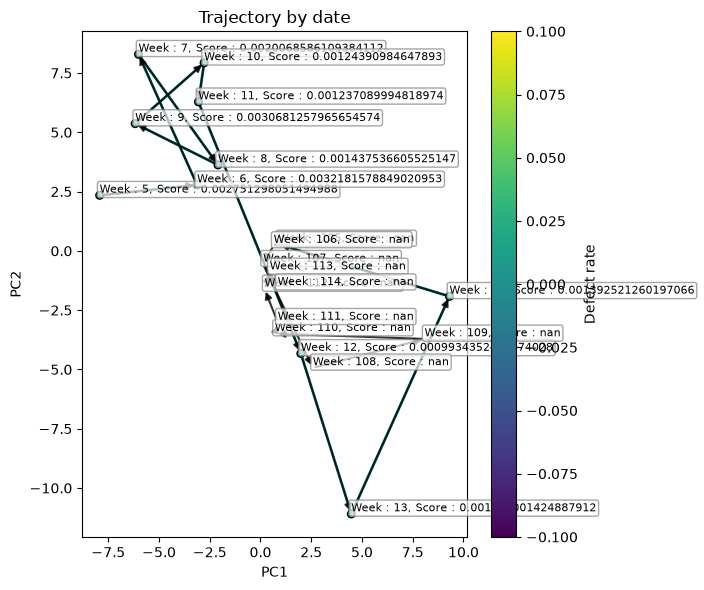

In [84]:


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_sv_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()